In [1]:
%load_ext autoreload

%autoreload 2

ERROR:tornado.general:Uncaught exception in ZMQStream callback
Traceback (most recent call last):
  File "/dss/dsshome1/00/di54xat/cloudsen12/.venv/lib64/python3.12/site-packages/traitlets/traitlets.py", line 632, in get
    value = obj._trait_values[self.name]
            ~~~~~~~~~~~~~~~~~^^^^^^^^^^^
KeyError: '_control_lock'

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/dss/dsshome1/00/di54xat/cloudsen12/.venv/lib64/python3.12/site-packages/zmq/eventloop/zmqstream.py", line 565, in _log_error
    f.result()
  File "/dss/dsshome1/00/di54xat/cloudsen12/.venv/lib64/python3.12/site-packages/ipykernel/kernelbase.py", line 347, in dispatch_control
    async with self._control_lock:
               ^^^^^^^^^^^^^^^^^^
  File "/dss/dsshome1/00/di54xat/cloudsen12/.venv/lib64/python3.12/site-packages/traitlets/traitlets.py", line 687, in __get__
    return t.cast(G, self.get(obj, cls))  # the G should encode the Optional
       

In [2]:
from submit_test import ModelTester

/dss/dsshome1/00/di54xat/cloudsen12/.venv/lib64/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:

from src.misc import select_patches_from_dataset
from src.dataset import TestS2TIFDataSet, TestS2TIFDataSet512
from src.model import UNet
from src.training.lwf_unet_aspp_trainer import UNet as ASPPUNet
from pathlib import Path


# Testing models
Idea is to train on no-label/scribble and test on high from cloudsen12

In [39]:

def define_tester(
    user: str,
    repo: str = "cloudsen12",
    seed:int = 42,
    csv_name: str = "cloudsen12_initial_high_test.csv",
    epochs: int = 16,
    patch_size: int = 256,
    batch_size: int = 12,
    num_workers: int = 16,
    prefetch_factor: int = 8,
    experiment_id: str = "cloudsen12_aspp_scribble_multitypecloud_256_001",
    partition: str = "hpda2_compute_gpu",
    time: str = "03:00:00",
    gpus_per_node: int = 1,
    mem_gb: int = 256,
    account: str = "pn39sa-c",
    clusters: str = "hpda2",
    mail_user: str | None = None,
    exclude_nodes: str | None = None,
):

    root_hpc = Path("/dss/dsstbyfs02/pn49ci/pn49ci-dss-0026")
    user_path = root_hpc / user
    log_dir = user_path / "experiments/LWF-DLR/slurm_logs/test"
    log_dir.mkdir(parents=True, exist_ok=True)

    cpus_per_task = 2 + num_workers

    experiment_group: str = "LWF-DLR"

    data_path = user_path / repo / "data"

    # Load dataset
    file_names = select_patches_from_dataset(
        data_path / csv_name, 
        data_path,
        type_folder="", # not supported here
    )

    use_aspp_trainer = True
    if use_aspp_trainer:
        model = ASPPUNet()
    else:
        model = UNet()


    if patch_size == 512:
        dataset = TestS2TIFDataSet512(
            file_names,
            seed
        )
    else: #default
        dataset = TestS2TIFDataSet(
            file_names,
            seed
        )

    model_name = "best_model.pth"
    tester = ModelTester(
        model,
        dataset,
        batch_size,
        num_workers, # cpus per task
        "cuda",
        user,
        repo,
        experiment_group, 
        experiment_id,
        model_name,
    )


    return tester, dataset, model

In [40]:
tester, dataset, model = define_tester("di54xat", num_workers=14) # not passing to slurm # working with 8 cpu threads

In [41]:
print(tester())

Test: 100%|██████████| 834/834 [01:38<00:00,  8.46it/s]


{
    "cross_entropy": 8.301773106880326,
    "dice_loss": 0.7137574927984096,
    "pixel_accuracy": 0.27850758209228516,
    "dice_per_class": [
        0.0012048419729064391,
        0.34541857356143657,
        0.0009507832106350694,
        0.002337886820594772
    ],
    "mean_dice": 0.08747802139139321,
    "iou_per_class": [
        0.0007396904347881979,
        0.2779993454121978,
        0.0005880959351867101,
        0.0014393579701691462
    ],
    "mean_iou": 0.07019162243808547
}


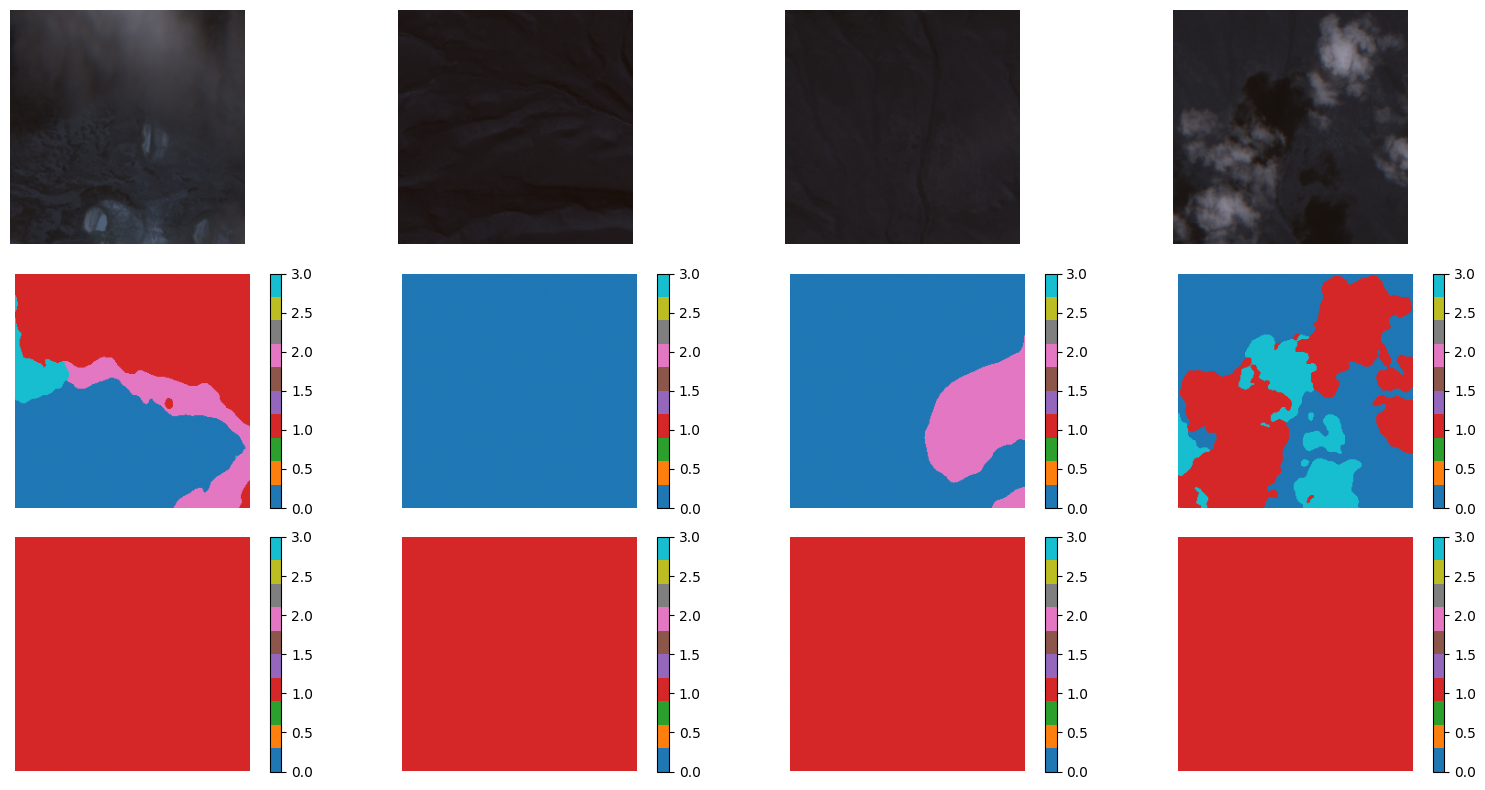

In [42]:
# check what the loader loads
import random
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 4, figsize=(16, 8))


for i in range(4):
    rand_id = i+4 # int(random.random() * len(train_dataset))
    sample_x, sample_y = dataset[rand_id]

    # model predict
    logits = model(sample_x.unsqueeze(0).to("cuda"))
    pred = logits.cpu().detach().argmax(dim=1).squeeze(0).numpy()

    im_pred = axes[2, i].imshow(pred, cmap="tab10", vmin=0, vmax=3)
    axes[2, i].axis("off")

    fig.colorbar(im_pred, ax=axes[2, i])

    # Plot input
    axes[0, i].imshow(sample_x[:3].permute(1,2,0).numpy())
    axes[0, i].axis("off")

    # Plot target
    im = axes[1, i].imshow(sample_y.numpy(), cmap="tab10", vmin=0, vmax=3)
    
    fig.colorbar(im, ax=axes[1, i])

    axes[1, i].axis("off")

#plt.colorbar()
plt.tight_layout()
plt.show()